In [1]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
df = pd.read_csv(
    "../data/processed/driver_race_features.csv"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (2618, 28)


,DriverNumber,Abbreviation,DriverId,TeamName,TeamId,FirstName,LastName,FullName,Position,ClassifiedPosition,...,Q1,Q2,Q3,Round,PreviousRaceFinish,BestQualifyingTime,QualifyingTimeGap,DriverHistoricalAvgFinish,DriverRecentForm,TeamHistoricalAvgFinish
0,77,BOT,bottas,Mercedes,mercedes,Valtteri,Bottas,Valtteri Bottas,1.0,1,...,64.111,63.015,62.939,1,NaN,62.939,0.000,NaN,NaN,NaN
1,16,LEC,leclerc,Ferrari,ferrari,Charles,Leclerc,Charles Leclerc,2.0,2,...,64.500,64.041,63.923,1,NaN,63.923,0.984,NaN,NaN,NaN
2,4,NOR,norris,McLaren,mclaren,Lando,Norris,Lando Norris,3.0,3,...,64.606,63.819,63.626,1,NaN,63.626,0.687,NaN,NaN,NaN
3,44,HAM,hamilton,Mercedes,mercedes,Lewis,Hamilton,Lewis Hamilton,4.0,4,...,64.198,63.096,62.951,1,NaN,62.951,0.012,NaN,NaN,NaN
4,55,SAI,sainz,McLaren,mclaren,Carlos,Sainz,Carlos Sainz,5.0,5,...,64.537,63.971,63.971,1,NaN,63.971,1.032,NaN,NaN,NaN


In [3]:
target = "Position"

print("Target:", target)

Target: Position


In [4]:
features = [
    "GridPosition",
    "QualifyingPosition",
    "BestQualifyingTime",
    "QualifyingTimeGap",
    "PreviousRaceFinish",
    "DriverHistoricalAvgFinish",
    "DriverRecentForm",
    "TeamHistoricalAvgFinish"
]

print("Number of features:", len(features))

Number of features: 8


In [5]:
train_df = df[df["Year"] <= 2023].copy()

validation_df = df[df["Year"] == 2024].copy()

test_df = df[df["Year"] == 2025].copy()

print("Training data:", train_df.shape)
print("Validation data:", validation_df.shape)
print("Test data:", test_df.shape)

Training data: (1660, 28)
Validation data: (479, 28)
Test data: (479, 28)


In [6]:
train_df = train_df.dropna(subset=["Position"])
validation_df = validation_df.dropna(subset=["Position"])
test_df = test_df.dropna(subset=["Position"])

print("Training data:", train_df.shape)
print("Validation data:", validation_df.shape)
print("Test data:", test_df.shape)

Training data: (1657, 28)
Validation data: (479, 28)
Test data: (479, 28)


In [7]:
X_train = train_df[features]
y_train = train_df[target]

X_validation = validation_df[features]
y_validation = validation_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1657, 8)
y_train: (1657,)
X_validation: (479, 8)
y_validation: (479,)
X_test: (479, 8)
y_test: (479,)


In [8]:
missing_values = X_train.isna().sum()

print("Missing values in training features:")
print(missing_values)

Missing values in training features:
GridPosition                  0
QualifyingPosition            1
BestQualifyingTime           17
QualifyingTimeGap            17
PreviousRaceFinish           35
DriverHistoricalAvgFinish    33
DriverRecentForm             33
TeamHistoricalAvgFinish      24
dtype: int64


In [9]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)

X_validation_imputed = imputer.transform(X_validation)

X_test_imputed = imputer.transform(X_test)

In [10]:
print("Training shape:", X_train_imputed.shape)
print("Validation shape:", X_validation_imputed.shape)
print("Test shape:", X_test_imputed.shape)

print("\nMissing values after imputation:")

print(
    "Training:",
    pd.DataFrame(X_train_imputed).isna().sum().sum()
)

print(
    "Validation:",
    pd.DataFrame(X_validation_imputed).isna().sum().sum()
)

print(
    "Test:",
    pd.DataFrame(X_test_imputed).isna().sum().sum()
)

Training shape: (1657, 8)
Validation shape: (479, 8)
Test shape: (479, 8)

Missing values after imputation:
Training: 0
Validation: 0
Test: 0


In [11]:
from sklearn.dummy import DummyRegressor

baseline_model = DummyRegressor(strategy="mean")

baseline_model.fit(
    X_train_imputed,
    y_train
)

baseline_predictions = baseline_model.predict(
    X_validation_imputed
)

print("Baseline model trained successfully!")

Baseline model trained successfully!


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_mae = mean_absolute_error(
    y_validation,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_validation,
    baseline_predictions
)

print("Baseline Performance")
print("--------------------")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)
print("R²  :", baseline_r2)

Baseline Performance
--------------------
MAE : 4.990569520336952
RMSE: 5.755920054540077
R²  : -2.0928934185704406e-07


In [13]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()

linear_model.fit(
    X_train_imputed,
    y_train
)
print("Model Trained")

linear_prediction = linear_model.predict(
    X_validation_imputed
)

print("Prediction generated")

Model Trained
Prediction generated


In [14]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np

linear_mae= mean_absolute_error(
    y_validation,
    linear_prediction
)

linear_rmse= np.sqrt(mean_squared_error(
    y_validation,
    linear_prediction
))

linear_r2 = r2_score(
    y_validation,
    linear_prediction
)

print("MAE:",linear_mae)
print("RMSE:",linear_rmse)
print("R2:",linear_r2)

MAE: 2.998062447773995
RMSE: 3.8601972472018344
R2: 0.5502309388856493


In [15]:
from sklearn.ensemble import RandomForestRegressor
random_forest = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
print("Forest Generated")

random_forest.fit(
    X_train_imputed,
    y_train
)
print("training done")

rf_predictions = random_forest.predict(
    X_validation_imputed
)
print("prediction generated.")

Forest Generated
training done
prediction generated.


In [16]:
rf_mae = mean_absolute_error(
    y_validation,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_validation,
    rf_predictions
)

print("Random Forest Performance")
print("-------------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Performance
-------------------------
MAE : 3.3201774530271395
RMSE: 4.231756367276276
R²  : 0.4594798395551153


In [17]:
%pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [18]:
import xgboost as xgb
print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [19]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    objective="reg:squarederror"
)
print("XGBoost model created successfully!")

xgb_model.fit(
    X_train_imputed,
    y_train
)
print("model trained")

xgb_predictions =xgb_model.predict(
    X_validation_imputed
)
print("prediction generated")

XGBoost model created successfully!
model trained
prediction generated


In [20]:
xgb_mae = mean_absolute_error(
    y_validation,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        xgb_predictions
    )
)

xgb_r2 = r2_score(
    y_validation,
    xgb_predictions
)

print("XGBoost Performance")
print("-------------------")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²  :", xgb_r2)

XGBoost Performance
-------------------
MAE : 3.169989464676206
RMSE: 4.092216928022875
R²  : 0.4945387355472942


In [21]:
model_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2": [
        baseline_r2,
        linear_r2,
        rf_r2,
        xgb_r2
    ]
})

model_results

,Model,MAE,RMSE,R2
0,Baseline,4.990570,5.755920,-2.092893e-07
1,Linear Regression,2.998062,3.860197,5.502309e-01
2,Random Forest,3.320177,4.231756,4.594798e-01
3,XGBoost,3.169989,4.092217,4.945387e-01


In [22]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": linear_model.coef_
})

coefficients = coefficients.sort_values(
    "Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
1,QualifyingPosition,0.365798
7,TeamHistoricalAvgFinish,0.335812
5,DriverHistoricalAvgFinish,0.114614
4,PreviousRaceFinish,0.046076
3,QualifyingTimeGap,0.037571
0,GridPosition,0.020872
6,DriverRecentForm,0.008919
2,BestQualifyingTime,-0.000550


In [23]:
final_predictions = linear_model.predict(
    X_test_imputed
)

print("2025 predictions generated successfully!")

2025 predictions generated successfully!


In [24]:
test_mae = mean_absolute_error(
    y_test,
    final_predictions
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_predictions
    )
)

test_r2 = r2_score(
    y_test,
    final_predictions
)

print("MAE :", test_mae)
print("RMSE:", test_rmse)
print("R²  :", test_r2)

MAE : 3.43566074141448
RMSE: 4.327498658397087
R²  : 0.4347449277137081


In [25]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [26]:
import shap

print("SHAP version:", shap.__version__)

c:\Users\chris\Desktop\APEX\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.52.0


In [27]:
explainer = shap.LinearExplainer(
    linear_model,
    X_train_imputed
)

print("SHAP explainer created successfully!")

Background dataset has 1657 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1657 when initializing the masker.


SHAP explainer created successfully!


In [28]:
shap_values = explainer(
    X_test_imputed
)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


In [29]:
%pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


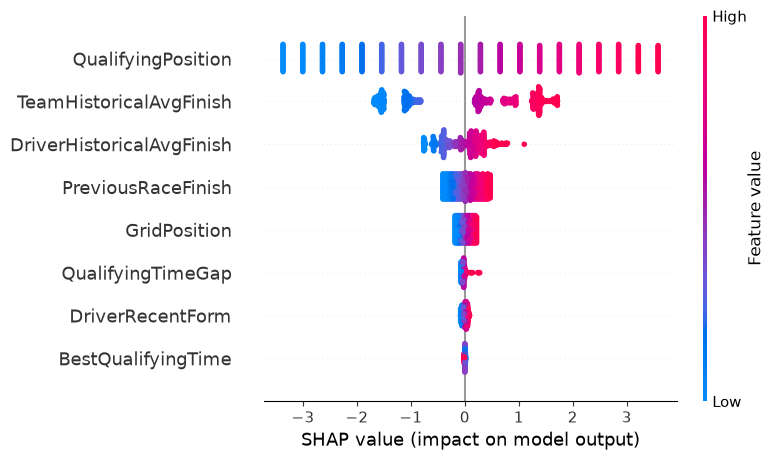

In [30]:
shap.summary_plot(
    shap_values.values,
    X_test_imputed,
    feature_names=features
)

In [31]:
sample_index = 0

print("Actual finishing position:",
      y_test.iloc[sample_index])

print("Predicted finishing position:",
      final_predictions[sample_index])

print("\nFeature values:")

sample_features = pd.DataFrame(
    X_test_imputed,
    columns=features
).iloc[sample_index]

print(sample_features)

Actual finishing position: 1.0
Predicted finishing position: 5.075435829394193

Feature values:
GridPosition                  1.000000
QualifyingPosition            1.000000
BestQualifyingTime           75.096000
QualifyingTimeGap             0.000000
PreviousRaceFinish            1.000000
DriverHistoricalAvgFinish     7.168224
DriverRecentForm              5.666667
TeamHistoricalAvgFinish       8.158879
Name: 0, dtype: float64


In [35]:
X_test_imputed_df = pd.DataFrame(
    X_test_imputed,
    columns=features
)

shap_values_named = explainer(
    X_test_imputed_df
)

print("SHAP values with feature names created!")

SHAP values with feature names created!


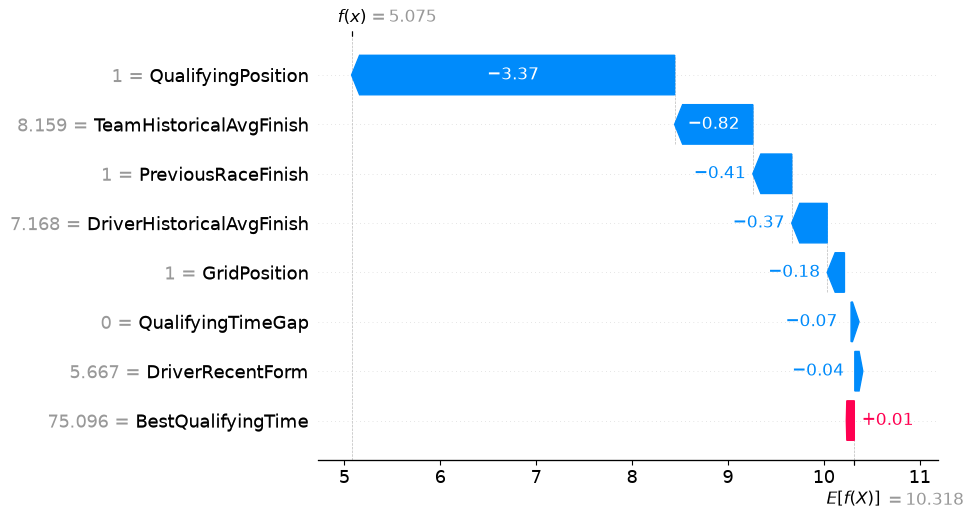

In [36]:
shap.plots.waterfall(
    shap_values_named[0]
)